# **Sentiment Analysis** - IMDB Dataset

Contains next sections:
- **Section 1:** Imports
- **Section 2:** Loading and preparing data
- **Section 3:** Split data
- **Section 4:** Algorithm 1
- **Section 5:** Algorithm 2
- **Section 6:** PCA analysis
- **Section 7:** Final testing on an independent test set
- **Section 8:** Data visualization
- **Section 9:** Final results and saving the model

## **Section 1:** Imports

In [1]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           classification_report, confusion_matrix, roc_curve, auc)

from sklearn.preprocessing import StandardScaler
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from nltk import FreqDist
import matplotlib.pyplot as plt
import seaborn as sns
import utils  # tvoj utils modul

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
import re
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iam0v\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\iam0v\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\iam0v\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

## **Section 2:** Loading and preparing data

In [4]:
print("="*50)
print("SENTIMENT ANALYSIS - IMDB Dataset")
print("="*50)

# Učitavanje podataka
texts = []
labels = []
directory = r"C:\Users\iam0v\Downloads\datasets\imdb\train\pos"
utils.load_data(directory, texts, labels)
directory = r"C:\Users\iam0v\Downloads\datasets\imdb\train\neg"
utils.load_data(directory, texts, labels)
directory = r"C:\Users\iam0v\Downloads\datasets\imdb\test\pos"
utils.load_data(directory, texts, labels)
directory = r"C:\Users\iam0v\Downloads\datasets\imdb\test\neg"
utils.load_data(directory, texts, labels)

# Preprocesiranje
texts = [utils.lemmatize(utils.remove_stopwords(utils.remove_breaklines(text))) for text in texts]
texts = [utils.clean_text(text) for text in texts]

print(f"Ukupno tekstova: {len(texts)}")
print(f"Ukupno labela: {len(labels)}")

SENTIMENT ANALYSIS - IMDB Dataset
Ukupno tekstova: 50000
Ukupno labela: 50000


## **Section 3:** Split data

In [5]:
# VAŽNO: Izdvajanje finalnog test skupa (15%) koji se ne koristi do kraja
X_temp, X_final_test, y_temp, y_final_test = train_test_split(
    texts, labels, test_size=0.15, random_state=42, stratify=labels
)

# Podela preostalog na train i validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Train set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Final test set: {len(X_final_test)} samples (izdvojen za finalno testiranje)")

Train set: 34000 samples
Validation set: 8500 samples
Final test set: 7500 samples (izdvojen za finalno testiranje)


## **Section 4:** Algorithm 1

In [6]:
print("\n--- Algoritam 1: LSTM ---")

# Priprema tokenizera
fdist = FreqDist()
for text in X_train:
    for word in text.split():
        fdist[word.lower()] += 1

num_of_words = len([word for word in fdist if fdist[word] > 3])
print(f"Broj reči u rečniku: {num_of_words}")

tokenizer_lstm = Tokenizer(num_words=num_of_words,
                          filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                          lower=True,
                          split=' ')
tokenizer_lstm.fit_on_texts(X_train)


--- Algoritam 1: LSTM ---
Broj reči u rečniku: 33949


In [7]:
# Sekvence
X_train_seq = tokenizer_lstm.texts_to_sequences(X_train)
X_val_seq = tokenizer_lstm.texts_to_sequences(X_val)
X_final_seq = tokenizer_lstm.texts_to_sequences(X_final_test)

# Padding
seq_lengths = [len(text.split()) for text in X_train]
max_length = max(seq_lengths)
print(f"Maksimalna dužina sekvence: {max_length}")

X_train_seq = pad_sequences(X_train_seq, max_length)
X_val_seq = pad_sequences(X_val_seq, max_length)
X_final_seq = pad_sequences(X_final_seq, max_length)

print(f"Shape training sekvenci: {X_train_seq.shape}")

Maksimalna dužina sekvence: 1545
Shape training sekvenci: (34000, 1545)


In [8]:
# Funkcija za kreiranje LSTM modela sa različitim hiperparametrima
def create_lstm_model(lstm_units1=32, lstm_units2=16, embedding_dim=10):
    model = Sequential()
    model.add(Embedding(num_of_words, embedding_dim))
    model.add(LSTM(lstm_units1, return_sequences=True))
    model.add(LSTM(lstm_units2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Kreiranje i treniranje najbolje LSTM konfiguracije
print("Treniranje LSTM modela...")
best_lstm = create_lstm_model(32, 16, 10)

# Callback funkcije
early_stopping = EarlyStopping(monitor='val_loss', patience=4, mode='min', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.001, mode='min', verbose=1)
checkpoint = ModelCheckpoint('sentiment_lstm_model.keras', monitor='val_loss', mode='min', save_best_only=True, verbose=1)

# Treniranje
history_lstm = best_lstm.fit(X_train_seq, np.array(y_train), 
                            epochs=10, batch_size=64, 
                            validation_data=(X_val_seq, np.array(y_val)),
                            callbacks=[early_stopping, reduce_lr, checkpoint],
                            verbose=1)

Treniranje LSTM modela...
Epoch 1/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7220 - loss: 0.5055
Epoch 1: val_loss improved from None to 0.31567, saving model to sentiment_lstm_model.keras
532/532 ━━━━━━━━━━━━━━━━━━━━ 725s 1s/step - accuracy: 0.8158 - loss: 0.3933 - val_accuracy: 0.8647 - val_loss: 0.3157 - learning_rate: 0.0010
Epoch 2/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9273 - loss: 0.2046
Epoch 2: val_loss improved from 0.31567 to 0.27820, saving model to sentiment_lstm_model.keras
532/532 ━━━━━━━━━━━━━━━━━━━━ 329s 619ms/step - accuracy: 0.9248 - loss: 0.2053 - val_accuracy: 0.8876 - val_loss: 0.2782 - learning_rate: 0.0010
Epoch 3/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9595 - loss: 0.1221
Epoch 3: val_loss did not improve from 0.27820
532/532 ━━━━━━━━━━━━━━━━━━━━ 274s 515ms/step - accuracy: 0.9541 - loss: 0.1357 - val_accuracy: 0.8787 - val_loss: 0.3183 - learning_rate: 0.0010
Epoch 4/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 0s 549m

In [9]:
# Evaluacija LSTM na validation setu
print("\n--- LSTM Evaluacija na Validation Setu ---")
lstm_val_pred_prob = best_lstm.predict(X_val_seq)
lstm_val_pred = (lstm_val_pred_prob > 0.5).astype(int).flatten()

lstm_val_acc = accuracy_score(y_val, lstm_val_pred)
lstm_val_prec = precision_score(y_val, lstm_val_pred)
lstm_val_rec = recall_score(y_val, lstm_val_pred)
lstm_val_f1 = f1_score(y_val, lstm_val_pred)

print(f"LSTM Validation rezultati:")
print(f"Accuracy: {lstm_val_acc:.4f}")
print(f"Precision: {lstm_val_prec:.4f}")
print(f"Recall: {lstm_val_rec:.4f}")
print(f"F1-score: {lstm_val_f1:.4f}")

# Classification report
print("\nDetaljni Classification Report za LSTM:")
print(classification_report(y_val, lstm_val_pred, target_names=['Negative', 'Positive']))


--- LSTM Evaluacija na Validation Setu ---
266/266 ━━━━━━━━━━━━━━━━━━━━ 29s 107ms/step
LSTM Validation rezultati:
Accuracy: 0.8734
Precision: 0.8497
Recall: 0.9073
F1-score: 0.8776

Detaljni Classification Report za LSTM:
              precision    recall  f1-score   support

    Negative       0.90      0.84      0.87      4250
    Positive       0.85      0.91      0.88      4250

    accuracy                           0.87      8500
   macro avg       0.88      0.87      0.87      8500
weighted avg       0.88      0.87      0.87      8500



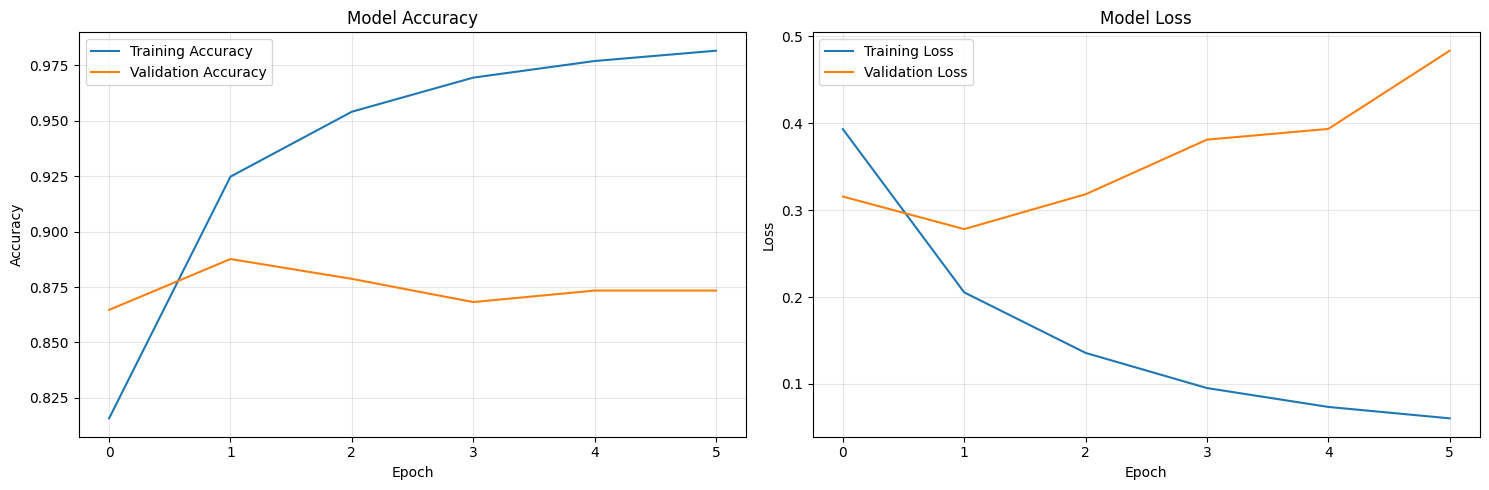

Najbolja validation accuracy: 0.8876
Finalna validation loss: 0.4836


In [10]:
# Vizualizacija training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_lstm.history['accuracy'], label='Training Accuracy')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_lstm.history['loss'], label='Training Loss')
axes[1].plot(history_lstm.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Najbolja validation accuracy: {max(history_lstm.history['val_accuracy']):.4f}")
print(f"Finalna validation loss: {history_lstm.history['val_loss'][-1]:.4f}")

## **Section 5:** Algorithm 2

In [11]:
print("\n--- Algoritam 2: SVM sa TF-IDF ---")

# TF-IDF vektorizacija - optimizovana
tfidf_sentiment = TfidfVectorizer(max_features=1000, stop_words='english', max_df=0.7, min_df=5, ngram_range=(1, 1))
X_train_tfidf = tfidf_sentiment.fit_transform(X_train)
X_val_tfidf = tfidf_sentiment.transform(X_val)
X_final_tfidf = tfidf_sentiment.transform(X_final_test)

print(f"TF-IDF shape: {X_train_tfidf.shape}")


--- Algoritam 2: SVM sa TF-IDF ---
TF-IDF shape: (34000, 1000)


In [12]:
# LinearSVC je MNOGO brži za linearne kernele
print("Grid Search za LinearSVC...")
param_grid_linear = {
    'C': [0.1, 1, 10]
}

linear_svc = LinearSVC(random_state=42, max_iter=1000)
grid_search_svm = GridSearchCV(linear_svc, param_grid_linear, 
                               cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search_svm.fit(X_train_tfidf, y_train)

# Ako treba probability, wrap sa CalibratedClassifierCV
best_svm = CalibratedClassifierCV(grid_search_svm.best_estimator_)
best_svm.fit(X_train_tfidf, y_train)

Grid Search za LinearSVC...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


,estimator,LinearSVC(C=0...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.1
,multi_class,'ovr'


In [13]:
# Evaluacija SVM na validation setu
print("\n--- SVM Evaluacija na Validation Setu ---")
svm_val_pred = best_svm.predict(X_val_tfidf)

svm_val_acc = accuracy_score(y_val, svm_val_pred)
svm_val_prec = precision_score(y_val, svm_val_pred)
svm_val_rec = recall_score(y_val, svm_val_pred)
svm_val_f1 = f1_score(y_val, svm_val_pred)

print(f"SVM Validation rezultati:")
print(f"Accuracy: {svm_val_acc:.4f}")
print(f"Precision: {svm_val_prec:.4f}")
print(f"Recall: {svm_val_rec:.4f}")
print(f"F1-score: {svm_val_f1:.4f}")

# Classification report
print("\nDetaljni Classification Report za SVM:")
print(classification_report(y_val, svm_val_pred, target_names=['Negative', 'Positive']))

# Feature importance za linearni SVM
# Uzmi underlying estimator iz calibrated_classifiers_
base_model = best_svm.calibrated_classifiers_[0].estimator

# Proveravamo da li je LinearSVC (koji je uvek linearan)
if hasattr(base_model, 'coef_'):
    feature_names = tfidf_sentiment.get_feature_names_out()
    coefficients = base_model.coef_[0]
    
    # Top pozitivne reči (za pozitivni sentiment)
    pos_indices = coefficients.argsort()[-10:][::-1]
    print(f"\nTop 10 reči za POZITIVNI sentiment:")
    for i, idx in enumerate(pos_indices):
        print(f"{i+1}. {feature_names[idx]}: {coefficients[idx]:.4f}")
    
    # Top negativne reči (za negativni sentiment) 
    neg_indices = coefficients.argsort()[:10]
    print(f"\nTop 10 reči za NEGATIVNI sentiment:")
    for i, idx in enumerate(neg_indices):
        print(f"{i+1}. {feature_names[idx]}: {coefficients[idx]:.4f}")
else:
    print("\nModel nema linearnih koeficijenata za prikaz feature importance.")


--- SVM Evaluacija na Validation Setu ---
SVM Validation rezultati:
Accuracy: 0.8612
Precision: 0.8503
Recall: 0.8767
F1-score: 0.8633

Detaljni Classification Report za SVM:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      4250
    Positive       0.85      0.88      0.86      4250

    accuracy                           0.86      8500
   macro avg       0.86      0.86      0.86      8500
weighted avg       0.86      0.86      0.86      8500


Top 10 reči za POZITIVNI sentiment:
1. excellent: 2.0336
2. great: 1.9498
3. best: 1.5098
4. superb: 1.4582
5. favorite: 1.4244
6. perfect: 1.3894
7. wonderful: 1.3874
8. illiant: 1.3254
9. amaze: 1.3170
10. fantastic: 1.2781

Top 10 reči za NEGATIVNI sentiment:
1. worst: -2.9939
2. waste: -2.8059
3. awful: -2.5129
4. bad: -2.1572
5. bore: -1.8634
6. poor: -1.8450
7. dull: -1.7611
8. poorly: -1.7395
9. terrible: -1.7024
10. fail: -1.6712


## **Section 6:** PCA analysis

In [14]:
print("\n--- Optimizovana PCA na TF-IDF features ---")

# Standardizacija pre PCA (važno za PCA)
scaler = StandardScaler(with_mean=False)  # with_mean=False jer je sparse matrix
X_train_scaled = scaler.fit_transform(X_train_tfidf)
X_val_scaled = scaler.transform(X_val_tfidf)

# Optimizovana PCA sa manjim brojem komponenti za brzinu
pca = PCA(n_components=100, random_state=42)  # Fiksiran broj umesto 95% varijanse
X_train_pca = pca.fit_transform(X_train_scaled.toarray())
X_val_pca = pca.transform(X_val_scaled.toarray())

print(f"Originalna dimenzionalnost: {X_train_tfidf.shape[1]}")
print(f"PCA dimenzionalnost: {X_train_pca.shape[1]}")
print(f"Objašnjena varijansa: {pca.explained_variance_ratio_.sum():.4f}")


--- Optimizovana PCA na TF-IDF features ---
Originalna dimenzionalnost: 1000
PCA dimenzionalnost: 100
Objašnjena varijansa: 0.1628


In [15]:
# Model bez PCA (već treniran)
scores_without_pca = cross_val_score(best_svm, X_val_tfidf, y_val, cv=3, scoring='f1')

# Model sa PCA
simple_svm_pca = LinearSVC(C=1.0, random_state=42)
simple_svm_pca.fit(X_train_pca, y_train)
scores_with_pca = cross_val_score(simple_svm_pca, X_val_pca, y_val, cv=3, scoring='f1')

print(f"F1 score bez PCA: {scores_without_pca.mean():.4f}")
print(f"F1 score sa PCA: {scores_with_pca.mean():.4f}")

if scores_without_pca.mean() > scores_with_pca.mean():
    print("SVM radi bolje BEZ PCA redukcije")
    final_svm_sentiment = best_svm
    use_pca_svm = False
else:
    print("SVM radi bolje SA PCA redukcijom")
    final_svm_sentiment = CalibratedClassifierCV(simple_svm_pca)
    final_svm_sentiment.fit(X_train_pca, y_train)
    use_pca_svm = True

F1 score bez PCA: 0.8445
F1 score sa PCA: 0.8505
SVM radi bolje SA PCA redukcijom


In [16]:
# Detaljno poređenje performansi sa i bez PCA
pca_comparison_data = {
    'Model': ['SVM (original)', 'SVM (PCA)'],
    'Features': [X_train_tfidf.shape[1], X_train_pca.shape[1]],
    'CV Score': [scores_without_pca.mean(), scores_with_pca.mean()],
    'Best Params': [str(grid_search_svm.best_params_), 'C=1.0 (default)']
}

df_pca_comparison = pd.DataFrame(pca_comparison_data)
print("\n=== PCA UTICAJ NA SVM PERFORMANSE ===")
display(df_pca_comparison)

# Validacija najbolji SVM modela (sa ili bez PCA)
if use_pca_svm:
    print("\n--- Evaluacija SVM sa PCA ---")
    svm_pca_pred = simple_svm_pca.predict(X_val_pca)
    svm_pca_acc = accuracy_score(y_val, svm_pca_pred)
    svm_pca_f1 = f1_score(y_val, svm_pca_pred)
    print(f"SVM+PCA Validation Accuracy: {svm_pca_acc:.4f}")
    print(f"SVM+PCA Validation F1-score: {svm_pca_f1:.4f}")
    
    final_svm_val_acc = svm_pca_acc
    final_svm_val_f1 = svm_pca_f1
else:
    print("\n--- SVM bez PCA je bolji ---")
    final_svm_val_acc = svm_val_acc
    final_svm_val_f1 = svm_val_f1

print(f"Finalna redukcija dimenzionalnosti: {((X_train_tfidf.shape[1] - X_train_pca.shape[1]) / X_train_tfidf.shape[1] * 100):.1f}%")


=== PCA UTICAJ NA SVM PERFORMANSE ===


,Model,Features,CV Score,Best Params
0,SVM (original),1000,0.844538,{'C': 0.1}
1,SVM (PCA),100,0.850507,C=1.0 (default)



--- Evaluacija SVM sa PCA ---
SVM+PCA Validation Accuracy: 0.8544
SVM+PCA Validation F1-score: 0.8569
Finalna redukcija dimenzionalnosti: 90.0%


## **Section 7:** Final testing on an independent test set

In [17]:
print("\n" + "="*50)
print("FINALNO TESTIRANJE NA NEZAVISNOM TEST SKUPU")
print("="*50)

print("\n--- SENTIMENT ANALYSIS ---")

# Kombinuj train i validation za finalno treniranje
X_full_train = X_train + X_val
y_full_train = y_train + y_val

print(f"Finalni training set: {len(X_full_train)} samples")


FINALNO TESTIRANJE NA NEZAVISNOM TEST SKUPU

--- SENTIMENT ANALYSIS ---
Finalni training set: 42500 samples


In [18]:
# 1. LSTM - retreniranje na celom skupu
tokenizer_final = Tokenizer(num_words=num_of_words,
                           filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                           lower=True, split=' ')
tokenizer_final.fit_on_texts(X_full_train)

X_full_seq = tokenizer_final.texts_to_sequences(X_full_train)
X_test_seq_final = tokenizer_final.texts_to_sequences(X_final_test)

X_full_seq = pad_sequences(X_full_seq, max_length)
X_test_seq_final = pad_sequences(X_test_seq_final, max_length)

final_lstm = create_lstm_model(32, 16, 10)
final_lstm.fit(X_full_seq, np.array(y_full_train), epochs=5, batch_size=128, verbose=0)

# Predikcije i mere za LSTM
lstm_pred = (final_lstm.predict(X_test_seq_final) > 0.5).astype(int).flatten()
lstm_acc = accuracy_score(y_final_test, lstm_pred)
lstm_prec = precision_score(y_final_test, lstm_pred)
lstm_rec = recall_score(y_final_test, lstm_pred)
lstm_f1 = f1_score(y_final_test, lstm_pred)

print(f"\nLSTM rezultati:")
print(f"Accuracy: {lstm_acc:.4f}")
print(f"Precision: {lstm_prec:.4f}")
print(f"Recall: {lstm_rec:.4f}")
print(f"F1-score: {lstm_f1:.4f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step

LSTM rezultati:
Accuracy: 0.8808
Precision: 0.8822
Recall: 0.8789
F1-score: 0.8806


In [19]:
# 2. SVM - finalno treniranje
X_full_tfidf = tfidf_sentiment.fit_transform(X_full_train)
X_test_tfidf_final = tfidf_sentiment.transform(X_final_test)

if use_pca_svm:
    X_full_scaled = scaler.fit_transform(X_full_tfidf)
    X_test_scaled = scaler.transform(X_test_tfidf_final)
    X_full_pca = pca.fit_transform(X_full_scaled.toarray())
    X_test_pca = pca.transform(X_test_scaled.toarray())
    final_svm_sentiment.fit(X_full_pca, y_full_train)
    svm_pred = final_svm_sentiment.predict(X_test_pca)
else:
    final_svm_sentiment.fit(X_full_tfidf, y_full_train)
    svm_pred = final_svm_sentiment.predict(X_test_tfidf_final)

svm_acc = accuracy_score(y_final_test, svm_pred)
svm_prec = precision_score(y_final_test, svm_pred)
svm_rec = recall_score(y_final_test, svm_pred)
svm_f1 = f1_score(y_final_test, svm_pred)

print(f"\nSVM rezultati:")
print(f"Accuracy: {svm_acc:.4f}")
print(f"Precision: {svm_prec:.4f}")
print(f"Recall: {svm_rec:.4f}")
print(f"F1-score: {svm_f1:.4f}")


SVM rezultati:
Accuracy: 0.8585
Precision: 0.8491
Recall: 0.8720
F1-score: 0.8604


In [20]:
# Detaljni finalni rezultati
print("\n=== DETALJNI FINALNI REZULTATI ===")

# Classification reports
print("\nLSTM Classification Report:")
print(classification_report(y_final_test, lstm_pred, target_names=['Negative', 'Positive']))

print("\nSVM Classification Report:")
print(classification_report(y_final_test, svm_pred, target_names=['Negative', 'Positive']))

# Confusion matrices kao DataFrame
cm_lstm_df = pd.DataFrame(confusion_matrix(y_final_test, lstm_pred), 
                         index=['Actual Negative', 'Actual Positive'],
                         columns=['Pred Negative', 'Pred Positive'])
print("\nLSTM Confusion Matrix:")
display(cm_lstm_df)

cm_svm_df = pd.DataFrame(confusion_matrix(y_final_test, svm_pred),
                        index=['Actual Negative', 'Actual Positive'], 
                        columns=['Pred Negative', 'Pred Positive'])
print("\nSVM Confusion Matrix:")
display(cm_svm_df)


=== DETALJNI FINALNI REZULTATI ===

LSTM Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      3750
    Positive       0.88      0.88      0.88      3750

    accuracy                           0.88      7500
   macro avg       0.88      0.88      0.88      7500
weighted avg       0.88      0.88      0.88      7500


SVM Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      3750
    Positive       0.85      0.87      0.86      3750

    accuracy                           0.86      7500
   macro avg       0.86      0.86      0.86      7500
weighted avg       0.86      0.86      0.86      7500


LSTM Confusion Matrix:


,Pred Negative,Pred Positive
Actual Negative,3310,440
Actual Positive,454,3296



SVM Confusion Matrix:


,Pred Negative,Pred Positive
Actual Negative,3169,581
Actual Positive,480,3270


In [21]:
# Analiza pogrešno klasifikovanih primera
print("\n=== ANALIZA POGREŠNO KLASIFIKOVANIH PRIMERA ===")

# Identifikuj pogrešne predikcije
lstm_errors = np.where(lstm_pred != y_final_test)[0]
svm_errors = np.where(svm_pred != y_final_test)[0]

print(f"LSTM greške: {len(lstm_errors)}/{len(y_final_test)} ({len(lstm_errors)/len(y_final_test)*100:.1f}%)")
print(f"SVM greške: {len(svm_errors)}/{len(y_final_test)} ({len(svm_errors)/len(y_final_test)*100:.1f}%)")

# Uzmi par primera grešaka za analizu
print(f"\nPrimeri LSTM grešaka:")
for i, idx in enumerate(lstm_errors[:3]):
    actual = "Positive" if y_final_test[idx] == 1 else "Negative"
    predicted = "Positive" if lstm_pred[idx] == 1 else "Negative"
    confidence = lstm_proba[idx] if 'lstm_proba' in locals() else "N/A"
    text_preview = X_final_test[idx][:200] + "..." if len(X_final_test[idx]) > 200 else X_final_test[idx]
    print(f"\n{i+1}. Actual: {actual}, Predicted: {predicted}")
    print(f"   Text: {text_preview}")

print(f"\nPrimeri SVM grešaka:")
for i, idx in enumerate(svm_errors[:3]):
    actual = "Positive" if y_final_test[idx] == 1 else "Negative" 
    predicted = "Positive" if svm_pred[idx] == 1 else "Negative"
    text_preview = X_final_test[idx][:200] + "..." if len(X_final_test[idx]) > 200 else X_final_test[idx]
    print(f"\n{i+1}. Actual: {actual}, Predicted: {predicted}")
    print(f"   Text: {text_preview}")

# Preklapanje grešaka
common_errors = np.intersect1d(lstm_errors, svm_errors)
print(f"\nOba modela greše na istim primerima: {len(common_errors)} slučajeva")


=== ANALIZA POGREŠNO KLASIFIKOVANIH PRIMERA ===
LSTM greške: 894/7500 (11.9%)
SVM greške: 1061/7500 (14.1%)

Primeri LSTM grešaka:

1. Actual: Positive, Predicted: Negative
   Text:  Murder Numbers  star Ryan Gosling Michael Pitt two rebellious high schoolers content perfect murder sake overcome shatter self esteem  Sandra Bullock play heroic thorn way plan Det  Cassie Mayweather...

2. Actual: Positive, Predicted: Negative
   Text: This one very  film overwhelm unlikely watch twice lifetime  other examples Claude Lanzmann s documentary Shoah Come See director s husband Elem Klimov   cover much unbearable territory different way ...

3. Actual: Negative, Predicted: Positive
   Text: This low budget film  set one location valley shield effect radiation  The cast  older man daughter  handsome visitor  couple  a tough buy gal   drifter  donkey radiation affect man  interact effect n...

Primeri SVM grešaka:

1. Actual: Positive, Predicted: Negative
   Text: A group teens decide take slum

## **Section 8:** Data visualization


--- Generisanje vizualizacija ---
--- Confusion Matrix - LSTM ---


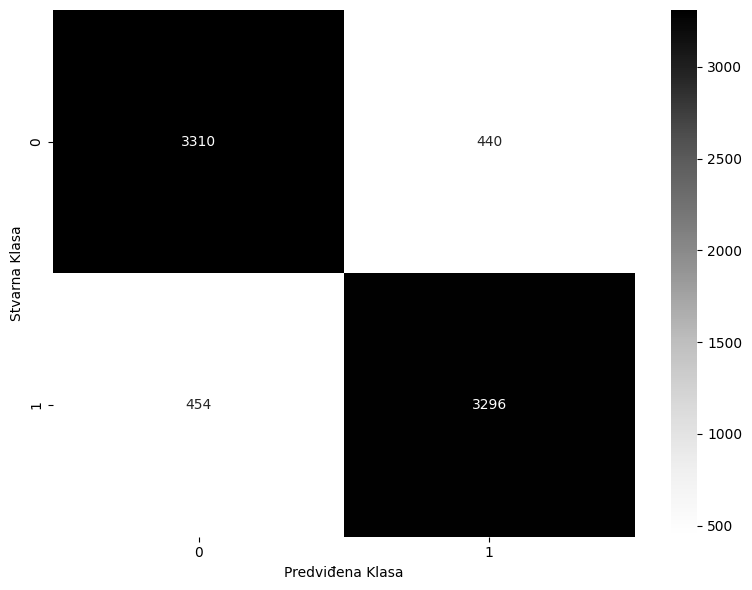

--- Finalna matrica konfuzije - SVM ---


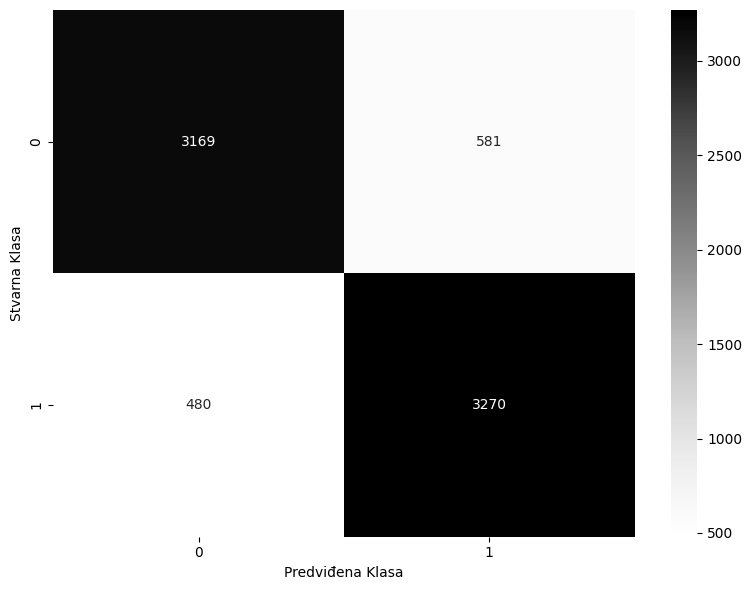

In [31]:
print("\n--- Generisanje vizualizacija ---")

print("--- Confusion Matrix - LSTM ---")

cm_lstm = confusion_matrix(y_final_test, lstm_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Grays')
plt.xlabel('Predviđena Klasa')
plt.ylabel('Stvarna Klasa')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("--- Finalna matrica konfuzije - SVM ---")

cm_svm = confusion_matrix(y_final_test, svm_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Grays')
plt.xlabel('Predviđena Klasa')
plt.ylabel('Stvarna Klasa')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step


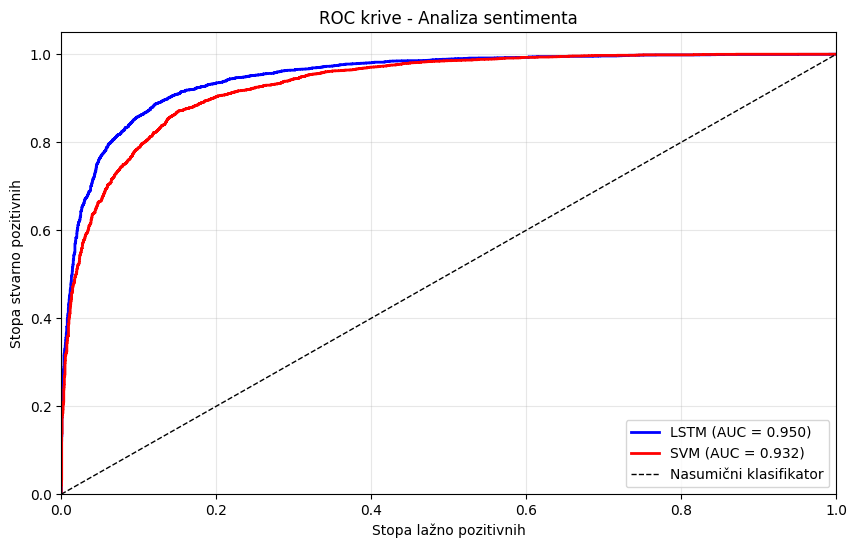

LSTM AUC: 0.9495
SVM AUC: 0.9321


In [32]:
# LSTM ROC - ponovno računanje verovatnoća
plt.figure(figsize=(10, 6))

if 'X_test_seq_final' in locals():
    lstm_proba = final_lstm.predict(X_test_seq_final).flatten()
else:
    lstm_proba = final_lstm.predict(X_final_seq).flatten()

fpr_lstm, tpr_lstm, _ = roc_curve(y_final_test, lstm_proba)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

# SVM ROC
if use_pca_svm and 'X_test_pca' in locals():
    svm_proba = final_svm_sentiment.predict_proba(X_test_pca)[:, 1]
else:
    svm_proba = final_svm_sentiment.predict_proba(X_test_tfidf_final)[:, 1]

fpr_svm, tpr_svm, _ = roc_curve(y_final_test, svm_proba)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_lstm, tpr_lstm, 'b-', linewidth=2, label=f'LSTM (AUC = {roc_auc_lstm:.3f})')
plt.plot(fpr_svm, tpr_svm, 'r-', linewidth=2, label=f'SVM (AUC = {roc_auc_svm:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Nasumični klasifikator')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Stopa lažno pozitivnih')
plt.ylabel('Stopa stvarno pozitivnih')
plt.title('ROC krive - Analiza sentimenta')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('roc_curves_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"LSTM AUC: {roc_auc_lstm:.4f}")
print(f"SVM AUC: {roc_auc_svm:.4f}")

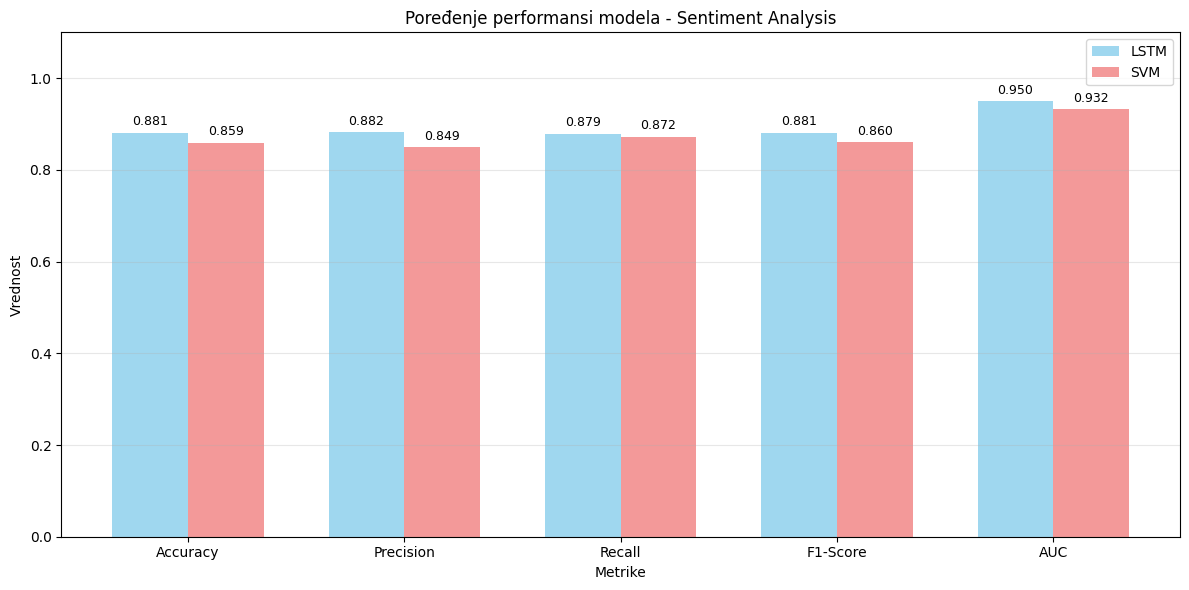

In [30]:
# Bar plot poređenja metrika
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'LSTM': [lstm_acc, lstm_prec, lstm_rec, lstm_f1, roc_auc_lstm],
    'SVM': [svm_acc, svm_prec, svm_rec, svm_f1, roc_auc_svm]
}

df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(12, 6))
x = np.arange(len(df_metrics['Metric']))
width = 0.35

plt.bar(x - width/2, df_metrics['LSTM'], width, label='LSTM', alpha=0.8, color='skyblue')
plt.bar(x + width/2, df_metrics['SVM'], width, label='SVM', alpha=0.8, color='lightcoral')

plt.xlabel('Metrike')
plt.ylabel('Vrednost')
plt.title('Poređenje performansi modela - Sentiment Analysis')
plt.xticks(x, df_metrics['Metric'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, 1.1)

# Dodaj vrednosti na vrh barova
for i, metric in enumerate(df_metrics['Metric']):
    plt.text(i - width/2, df_metrics['LSTM'][i] + 0.01, f'{df_metrics["LSTM"][i]:.3f}', 
             ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, df_metrics['SVM'][i] + 0.01, f'{df_metrics["SVM"][i]:.3f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

## **Section 9:** Final results and saving the model

In [25]:
# Poređenje algoritama za sentiment analizu
results_df = pd.DataFrame({
    'Algorithm': ['LSTM', 'SVM'],
    'Accuracy': [lstm_acc, svm_acc],
    'Precision': [lstm_prec, svm_prec],
    'Recall': [lstm_rec, svm_rec],
    'F1-score': [lstm_f1, svm_f1],
    'Dimensionality Reduction': ['None', 'PCA' if use_pca_svm else 'None']
})

print("\n" + "="*50)
print("FINALNI REZULTATI - SENTIMENT ANALYSIS")
print("="*50)
print(results_df.to_string(index=False))


FINALNI REZULTATI - SENTIMENT ANALYSIS
Algorithm  Accuracy  Precision   Recall  F1-score Dimensionality Reduction
     LSTM  0.880800   0.882227 0.878933  0.880577                     None
      SVM  0.858533   0.849130 0.872000  0.860413                      PCA


In [26]:
print("\n--- Čuvanje modela ---")
joblib.dump(final_svm_sentiment, 'final_svm_sentiment_model.pkl')
joblib.dump(tfidf_sentiment, 'tfidf_sentiment_vectorizer.pkl')
joblib.dump(pca, 'pca_transformer.pkl')
final_lstm.save("final_lstm_sentiment_model.keras")

print("Svi sentiment analysis modeli su sačuvani!")
print("- final_svm_sentiment_model.pkl")
print("- tfidf_sentiment_vectorizer.pkl") 
print("- pca_transformer.pkl")
print("- final_lstm_sentiment_model.h5")


--- Čuvanje modela ---
Svi sentiment analysis modeli su sačuvani!
- final_svm_sentiment_model.pkl
- tfidf_sentiment_vectorizer.pkl
- pca_transformer.pkl
- final_lstm_sentiment_model.h5
